# 上证指数高低开 0.7% 后三日表现（2020 至今）

本笔记用于评估信号日开盘后立即进场，并持有至信号日算第 1 天、第三个交易日收盘（T+2）的历史表现。结果是描述性统计，不含交易成本，也不构成投资建议。

## Context & Methods

- 大盘：上证指数 `sh000001`。
- 开盘缺口：`当日开盘 / 前一交易日收盘 - 1`。
- 低开：缺口 ≤ -0.7%；高开：缺口 ≥ +0.7%。
- 第三天收盘：信号日为第 1 天，对应 T+2 收盘。
- 收益基准：信号日开盘价，模拟开盘后立即进场。
- 三日最大有利/不利波动使用 T0 至 T+2 的最高价/最低价计算。

In [1]:
from pathlib import Path
from statistics import NormalDist
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
CACHE = ROOT / 'cache' / 'index_kline_cache.parquet'
OUT = ROOT / 'output' / 'research' / 'market_gap'
OUT.mkdir(parents=True, exist_ok=True)
START = pd.Timestamp('2020-01-01')
INDEX_CODE = 'sh000001'
THRESHOLD = 0.7
plt.style.use('seaborn-whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


## Data

读取项目本地指数日线缓存，并检查日期重复、关键字段缺失和来源。

In [2]:
columns = ['代码', '日期', '开盘', '最高', '最低', '收盘', '来源']
raw = pd.read_parquet(CACHE, columns=columns)
market = raw.loc[(raw['代码'] == INDEX_CODE) & (raw['日期'] >= START)].copy()
market = market.sort_values('日期').reset_index(drop=True)
quality = {
    'rows': int(len(market)),
    'start': market['日期'].min().date().isoformat(),
    'end': market['日期'].max().date().isoformat(),
    'duplicate_dates': int(market['日期'].duplicated().sum()),
    'missing_ohlc': int(market[['开盘','最高','最低','收盘']].isna().any(axis=1).sum()),
    'sources': market['来源'].value_counts(dropna=False).to_dict(),
}
quality

{'rows': 1624,
 'start': '2020-01-02',
 'end': '2026-09-11',
 'duplicate_dates': 0,
 'missing_ohlc': 0,
 'sources': {'ak': 1624}}

## Results

In [3]:
market['前收'] = market['收盘'].shift(1)
market['开盘缺口%'] = (market['开盘'] / market['前收'] - 1) * 100
for horizon in range(3):
    market[f'T+{horizon}收盘收益%'] = (market['收盘'].shift(-horizon) / market['开盘'] - 1) * 100
market['T+2相对前收%'] = (market['收盘'].shift(-2) / market['前收'] - 1) * 100
market['三日最高'] = pd.concat([market['最高'].shift(-i) for i in range(3)], axis=1).max(axis=1)
market['三日最低'] = pd.concat([market['最低'].shift(-i) for i in range(3)], axis=1).min(axis=1)
market['三日最大有利波动%'] = (market['三日最高'] / market['开盘'] - 1) * 100
market['三日最大不利波动%'] = (market['三日最低'] / market['开盘'] - 1) * 100
market['三日向上回补缺口'] = market['三日最高'] >= market['前收']
market['三日向下回补缺口'] = market['三日最低'] <= market['前收']
market['信号'] = np.select(
    [market['开盘缺口%'] <= -THRESHOLD, market['开盘缺口%'] >= THRESHOLD],
    ['低开≥0.7%', '高开≥0.7%'],
    default='普通交易日',
)
eligible = market.iloc[:-2].copy()
events = eligible.loc[eligible['信号'] != '普通交易日'].copy()

In [4]:
def wilson_interval(successes, total, alpha=0.05):
    if total == 0:
        return (np.nan, np.nan)
    z = NormalDist().inv_cdf(1 - alpha / 2)
    p = successes / total
    denom = 1 + z*z/total
    center = (p + z*z/(2*total)) / denom
    half = z * np.sqrt(p*(1-p)/total + z*z/(4*total*total)) / denom
    return ((center-half)*100, (center+half)*100)

def summarize(group):
    r = group['T+2收盘收益%'].dropna()
    wins = int((r > 0).sum())
    ci_lo, ci_hi = wilson_interval(wins, len(r))
    mean_half = 1.96 * r.std(ddof=1) / np.sqrt(len(r))
    return pd.Series({
        '样本数': len(r),
        '平均缺口%': group['开盘缺口%'].mean(),
        'T0收盘平均%': group['T+0收盘收益%'].mean(),
        'T+1收盘平均%': group['T+1收盘收益%'].mean(),
        'T+2收盘平均%': r.mean(),
        'T+2中位数%': r.median(),
        'T+2平均95%CI下限': r.mean() - mean_half,
        'T+2平均95%CI上限': r.mean() + mean_half,
        'T+2上涨概率%': wins / len(r) * 100,
        '上涨概率95%CI下限': ci_lo,
        '上涨概率95%CI上限': ci_hi,
        'T+2收益25分位%': r.quantile(.25),
        'T+2收益75分位%': r.quantile(.75),
        'T+2相对前收平均%': group['T+2相对前收%'].mean(),
        'T+2收复前收概率%': (group['T+2相对前收%'] > 0).mean() * 100,
        '三日平均最大有利%': group['三日最大有利波动%'].mean(),
        '三日平均最大不利%': group['三日最大不利波动%'].mean(),
        'T+2最差%': r.min(),
        'T+2最好%': r.max(),
    })

summary = pd.concat({
    '低开≥0.7%': summarize(events.loc[events['信号'] == '低开≥0.7%']),
    '高开≥0.7%': summarize(events.loc[events['信号'] == '高开≥0.7%']),
    '全部交易日基线': summarize(eligible),
}, axis=1).T
display(summary.round(3))

,样本数,平均缺口%,T0收盘平均%,T+1收盘平均%,T+2收盘平均%,T+2中位数%,T+2平均95%CI下限,T+2平均95%CI上限,T+2上涨概率%,上涨概率95%CI下限,上涨概率95%CI上限,T+2收益25分位%,T+2收益75分位%,T+2相对前收平均%,T+2收复前收概率%,三日平均最大有利%,三日平均最大不利%,T+2最差%,T+2最好%
低开≥0.7%,78.0,-1.308,0.194,0.103,0.121,0.063,-0.501,0.743,50.000,39.167,60.833,-1.041,1.911,-1.194,35.897,1.901,-2.008,-8.383,6.917
高开≥0.7%,56.0,1.401,0.132,0.504,0.786,0.684,-0.068,1.640,60.714,47.633,72.420,-0.844,1.993,2.179,76.786,2.209,-1.468,-10.137,14.453
全部交易日基线,1622.0,-0.057,0.078,0.099,0.119,0.115,0.033,0.206,54.007,51.575,56.421,-0.817,1.065,0.062,52.219,1.172,-1.182,-10.137,15.300


In [5]:
low = events.loc[events['信号'] == '低开≥0.7%']
high = events.loc[events['信号'] == '高开≥0.7%']
gap_fill = pd.DataFrame({
    '样本数': [len(low), len(high)],
    '三日回补前收概率%': [low['三日向上回补缺口'].mean()*100, high['三日向下回补缺口'].mean()*100],
}, index=['低开≥0.7%', '高开≥0.7%'])
display(gap_fill.round(2))

,样本数,三日回补前收概率%
低开≥0.7%,78,57.69
高开≥0.7%,56,46.43


### 缺口强度分层

In [6]:
events['缺口绝对值%'] = events['开盘缺口%'].abs()
events['缺口档位'] = pd.cut(events['缺口绝对值%'], bins=[0.7, 1.0, 1.5, np.inf], right=False, labels=['0.7–1.0%', '1.0–1.5%', '≥1.5%'])
severity = events.groupby(['信号', '缺口档位'], observed=True).apply(summarize, include_groups=False)
display(severity[['样本数','T0收盘平均%','T+1收盘平均%','T+2收盘平均%','T+2中位数%','T+2上涨概率%','三日平均最大有利%','三日平均最大不利%']].round(3))

样本数  T0收盘平均%  T+1收盘平均%  T+2收盘平均%  T+2中位数%  T+2上涨概率%  \
信号      缺口档位                                                             
低开≥0.7% 0.7–1.0%  40.0    0.221     0.213     0.210    0.625    57.500   
        1.0–1.5%  23.0    0.377    -0.257    -0.545   -0.361    30.435   
        ≥1.5%     15.0   -0.161     0.361     0.906    0.814    60.000   
高开≥0.7% 0.7–1.0%  26.0    0.312     0.335     0.520    0.519    57.692   
        1.0–1.5%  19.0    0.261     0.782     1.493    1.203    73.684   
        ≥1.5%     11.0   -0.516     0.425     0.193   -0.112    45.455   

                  三日平均最大有利%  三日平均最大不利%  
信号      缺口档位                            
低开≥0.7% 0.7–1.0%      1.789     -1.787  
        1.0–1.5%      1.756     -2.348  
        ≥1.5%         2.423     -2.077  
高开≥0.7% 0.7–1.0%      1.591     -1.259  
        1.0–1.5%      2.086     -1.070  
        ≥1.5%         3.881     -2.648

### 年度稳定性与不重叠信号检查

In [7]:
events['年份'] = events['日期'].dt.year
yearly = events.groupby(['年份','信号']).agg(
    样本数=('T+2收盘收益%', 'size'),
    平均收益=('T+2收盘收益%', 'mean'),
    中位收益=('T+2收盘收益%', 'median'),
    上涨概率=('T+2收盘收益%', lambda s: (s > 0).mean()*100),
).reset_index()
display(yearly.round(3))

def non_overlapping(group, span=3):
    chosen = []
    last_position = -span
    positions = group.index.to_numpy()
    for position in positions:
        if position - last_position >= span:
            chosen.append(position)
            last_position = position
    return market.loc[chosen]

robust = pd.concat({
    signal: summarize(non_overlapping(events.loc[events['信号'] == signal]))
    for signal in ['低开≥0.7%', '高开≥0.7%']
}, axis=1).T
display(robust[['样本数','T+2收盘平均%','T+2中位数%','T+2上涨概率%']].round(3))

,年份,信号,样本数,平均收益,中位收益,上涨概率
0,2020,低开≥0.7%,22,-0.263,-0.430,36.364
1,2020,高开≥0.7%,16,1.070,0.792,62.500
2,2021,低开≥0.7%,10,-0.088,0.176,50.000
3,2021,高开≥0.7%,5,-0.284,-1.228,40.000
4,2022,低开≥0.7%,18,0.513,1.162,61.111
5,2022,高开≥0.7%,8,0.579,0.929,75.000
6,2023,低开≥0.7%,1,-0.303,-0.303,0.000
7,2023,高开≥0.7%,5,-0.528,-0.724,40.000
8,2024,低开≥0.7%,5,1.372,2.915,60.000
9,2024,高开≥0.7%,10,1.885,0.940,50.000


,样本数,T+2收盘平均%,T+2中位数%,T+2上涨概率%
低开≥0.7%,61.0,-0.013,-0.126,47.541
高开≥0.7%,47.0,0.941,0.674,59.574


### 收益路径与分布

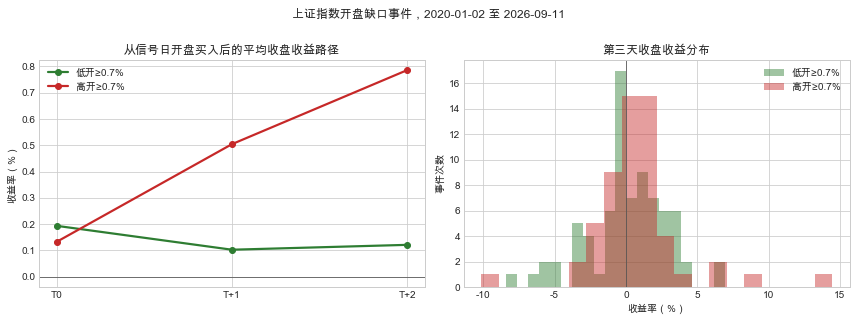

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
path_cols = ['T+0收盘收益%', 'T+1收盘收益%', 'T+2收盘收益%']
for signal, color in [('低开≥0.7%', '#2e7d32'), ('高开≥0.7%', '#c62828')]:
    values = events.loc[events['信号'] == signal, path_cols].mean()
    axes[0].plot(['T0', 'T+1', 'T+2'], values.to_numpy(), marker='o', linewidth=2.2, label=signal, color=color)
axes[0].axhline(0, color='#555', linewidth=.8)
axes[0].set_title('从信号日开盘买入后的平均收盘收益路径')
axes[0].set_ylabel('收益率（%）')
axes[0].legend()

for signal, color in [('低开≥0.7%', '#2e7d32'), ('高开≥0.7%', '#c62828')]:
    distribution = events.loc[events['信号'] == signal, 'T+2收盘收益%'].to_numpy()
    axes[1].hist(distribution, bins=20, alpha=.45, label=signal, color=color)
axes[1].axvline(0, color='#555', linewidth=.8)
axes[1].set_title('第三天收盘收益分布')
axes[1].set_xlabel('收益率（%）')
axes[1].set_ylabel('事件次数')
axes[1].legend()
fig.suptitle(f'上证指数开盘缺口事件，{quality["start"]} 至 {quality["end"]}')
fig.tight_layout(rect=[0, 0, 1, 0.90])
chart_path = OUT / 'market_gap_paths.png'
fig.savefig(chart_path, dpi=160, bbox_inches='tight')
plt.show()

## Takeaways

下列单元格根据执行结果生成摘要；实际交易判断仍需结合趋势、波动和事件环境。

In [9]:
low_row, high_row, base_row = summary.loc['低开≥0.7%'], summary.loc['高开≥0.7%'], summary.loc['全部交易日基线']
display(Markdown(
    f"- **低开样本 {int(low_row['样本数'])} 次**：T+2 平均 {low_row['T+2收盘平均%']:+.2f}%，中位数 {low_row['T+2中位数%']:+.2f}%，上涨概率 {low_row['T+2上涨概率%']:.1f}%。\n"
    f"- **高开样本 {int(high_row['样本数'])} 次**：T+2 平均 {high_row['T+2收盘平均%']:+.2f}%，中位数 {high_row['T+2中位数%']:+.2f}%，上涨概率 {high_row['T+2上涨概率%']:.1f}%。\n"
    f"- **全部交易日基线**：T+2 平均 {base_row['T+2收盘平均%']:+.2f}%，上涨概率 {base_row['T+2上涨概率%']:.1f}%。"
))

event_columns = ['日期','信号','开盘缺口%','开盘','前收','T+0收盘收益%','T+1收盘收益%','T+2收盘收益%','T+2相对前收%','三日最大有利波动%','三日最大不利波动%']
events[event_columns].to_csv(OUT / 'market_gap_events.csv', index=False, encoding='utf-8-sig')
summary.round(6).to_csv(OUT / 'market_gap_summary.csv', encoding='utf-8-sig')
severity.round(6).to_csv(OUT / 'market_gap_severity.csv', encoding='utf-8-sig')
yearly.round(6).to_csv(OUT / 'market_gap_yearly.csv', index=False, encoding='utf-8-sig')
result_payload = {
    'data_quality': quality,
    'summary': summary.reset_index(names='signal').round(6).to_dict(orient='records'),
    'gap_fill': gap_fill.reset_index(names='signal').round(6).to_dict(orient='records'),
    'robust_non_overlapping': robust.reset_index(names='signal').round(6).to_dict(orient='records'),
}
(OUT / 'market_gap_result.json').write_text(json.dumps(result_payload, ensure_ascii=False, indent=2), encoding='utf-8')
OUT

- **低开样本 78 次**：T+2 平均 +0.12%，中位数 +0.06%，上涨概率 50.0%。
- **高开样本 56 次**：T+2 平均 +0.79%，中位数 +0.68%，上涨概率 60.7%。
- **全部交易日基线**：T+2 平均 +0.12%，上涨概率 54.0%。

PosixPath('/Users/dong_007/D/stock/output/research/market_gap')